# Analyse sismique — Risque de tsunami & prédiction de magnitude

**Aide à la décision pour un système d'alerte précoce.** À partir du catalogue
USGS (M≥5.5, 1965-2024, ~28 000 séismes), ce notebook raconte le projet en 5
temps :

1. Ingestion & aperçu des données
2. Dynamique temporelle de la sismicité (Prophet)
3. Classification du risque de tsunami (données déséquilibrées)
4. Régression de la magnitude
5. Lecture spatiale (hotspots de subduction)

> La logique lourde vit dans `src/` ; ce notebook orchestre et commente.

In [1]:
import sys, warnings, logging
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)
logging.getLogger("prophet").setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.figsize"] = (11, 4.5)

import preprocessing as prep
from preprocessing import RAW_CSV, PROCESSED_CSV

## 1. Ingestion & aperçu

Le catalogue est téléchargé via l'API USGS (`src/data_download.py`, paginé par
année). Si les données brutes sont absentes (clone frais), décommentez la ligne
de téléchargement.

In [2]:
# Télécharger si nécessaire (~2-3 min). Décommentez sur un clone frais :
# import data_download; data_download.main()  # équiv. CLI par défaut

df = prep.build_features(prep.clean(prep.load_raw()))
print(f"{len(df):,} séismes naturels | {df.year.min()}-{df.year.max()}")
print(f"Taux tsunami : {100*df.tsunami.mean():.2f}%  "
      f"({int(df.tsunami.sum())} événements positifs)")
df[["datetime","latitude","longitude","depth","mag","magType","tsunami"]].head()

28,044 séismes naturels | 1965-2024
Taux tsunami : 2.40%  (674 événements positifs)


,datetime,latitude,longitude,depth,mag,magType,tsunami
0,1965-01-01 21:38:31.360000+00:00,35.703,4.391,12.4,5.64,mw,0
1,1965-01-02 13:44:18.920000+00:00,19.246,145.616,131.6,5.98,mw,0
2,1965-01-04 11:29:49.500000+00:00,1.863,127.352,80.0,5.76,mw,0
3,1965-01-05 00:51:32.710000+00:00,-7.366,106.637,71.3,5.51,mw,0
4,1965-01-05 18:05:58.930000+00:00,-20.601,-173.959,20.0,6.16,mw,0


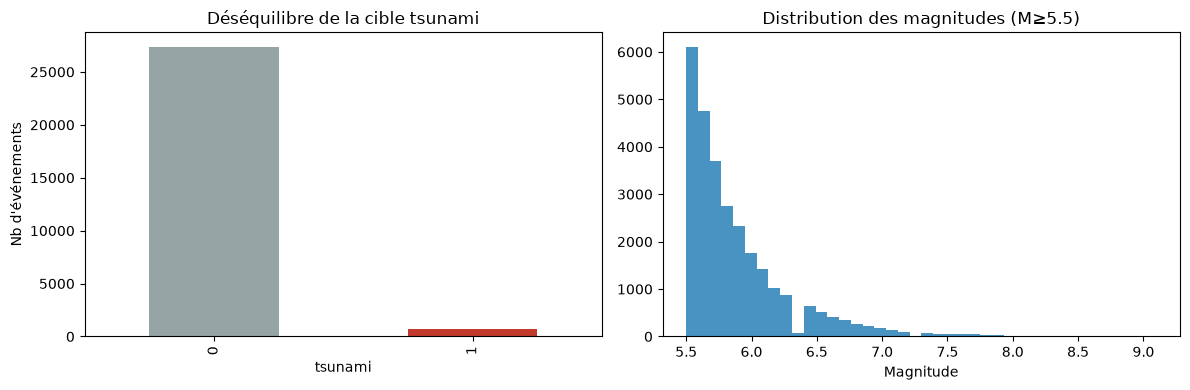

In [3]:
# Déséquilibre de classes + distribution de magnitude
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df.tsunami.value_counts().plot.bar(ax=ax[0], color=["#95a5a6","#c0392b"])
ax[0].set(title="Déséquilibre de la cible tsunami", xticklabels=["0","1"],
          ylabel="Nb d'événements")
ax[1].hist(df.mag, bins=40, color="#2980b9", alpha=0.85)
ax[1].set(title="Distribution des magnitudes (M≥5.5)", xlabel="Magnitude")
plt.tight_layout(); plt.show()

## 2. Dynamique temporelle (Prophet)

On agrège les événements par mois et on ajuste **Prophet** pour séparer
**tendance** et **saisonnalité annuelle**. La sismicité tectonique n'étant pas
saisonnière, on s'attend à une composante annuelle faible ; la tendance haussière
est surtout un **artefact de densification du réseau de détection**.

03:41:59 - cmdstanpy - INFO - Chain [1] start processing


03:41:59 - cmdstanpy - INFO - Chain [1] done processing


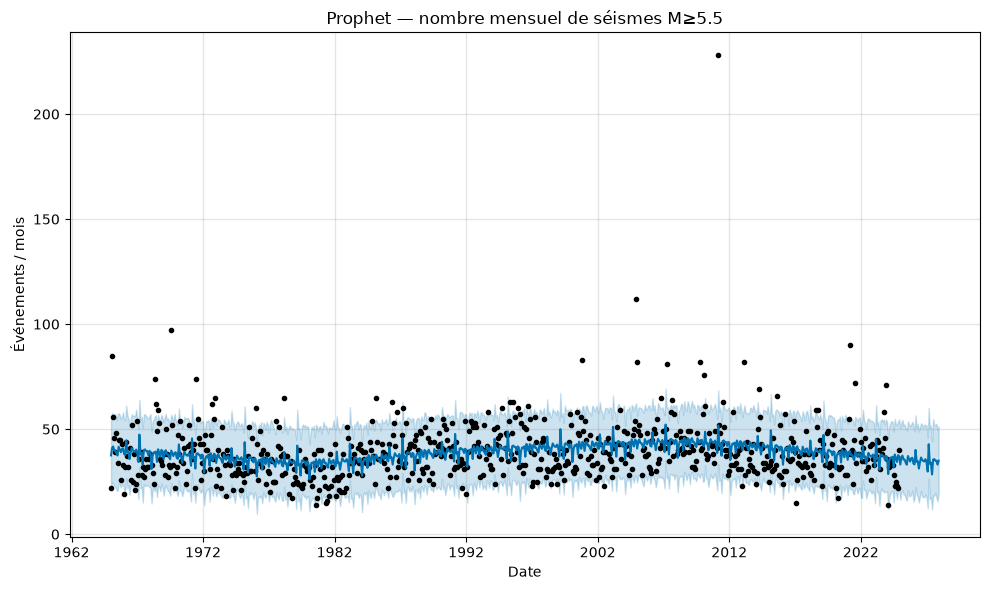

Amplitude saisonnière annuelle : 15.9 événements/mois (niveau moyen 39) -> faible.


In [4]:
from timeseries import monthly_counts, fit_prophet
series = monthly_counts(df)
model, forecast = fit_prophet(series, periods=36)

fig = model.plot(forecast)
fig.gca().set(title="Prophet — nombre mensuel de séismes M≥5.5",
              xlabel="Date", ylabel="Événements / mois")
plt.tight_layout(); plt.show()

amp = forecast.set_index("ds")["yearly"]
print(f"Amplitude saisonnière annuelle : {amp.max()-amp.min():.1f} "
      f"événements/mois (niveau moyen {series.y.mean():.0f}) -> faible.")

## 3. Classification du risque de tsunami

Cible à **2,4 %** de positifs : on compare 4 stratégies de déséquilibre et on
évalue avec **PR-AUC** et **rappel** (pas l'accuracy).

In [5]:
from sklearn.model_selection import train_test_split
from classification import build_models, evaluate, threshold_for_recall, plot_curves

X, y = prep.classification_matrix(df)
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=prep.RANDOM_STATE)
spw = (y_tr==0).sum() / max((y_tr==1).sum(), 1)

rows, probas = [], {}
for name, m in build_models(spw).items():
    met, proba = evaluate(name, m, X_tr, y_tr, X_te, y_te)
    rows.append(met); probas[name] = proba
res = pd.DataFrame(rows).sort_values("PR_AUC", ascending=False).reset_index(drop=True)
res.round(3)

,model,ROC_AUC,PR_AUC,F1@0.5,precision@0.5,recall@0.5
0,XGBoost (scale_pos_weight),0.948,0.254,0.320,0.207,0.708
1,RandomForest (balanced),0.932,0.232,0.232,0.222,0.244
2,RandomForest + SMOTE,0.926,0.178,0.274,0.209,0.399
3,LogReg (balanced),0.909,0.153,0.191,0.108,0.839


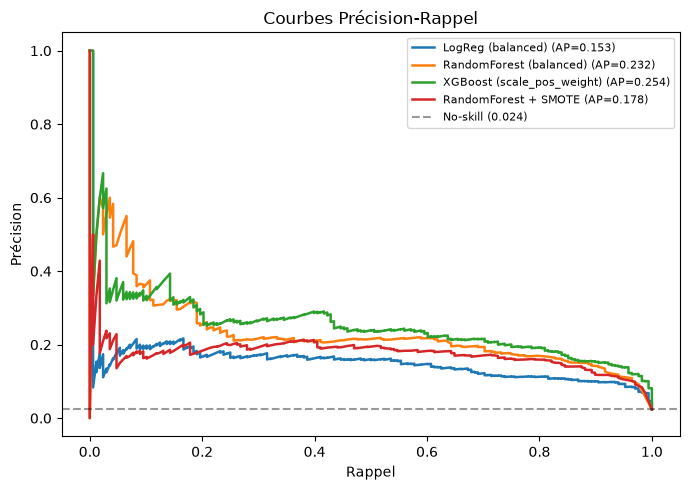

In [6]:
from sklearn.metrics import precision_recall_curve, average_precision_score
# Courbes PR (les plus pertinentes vu le déséquilibre)
fig, ax = plt.subplots(figsize=(7, 5))
for name, proba in probas.items():
    prec, rec, _ = precision_recall_curve(y_te, proba)
    ax.plot(rec, prec, lw=1.8, label=f"{name} (AP={average_precision_score(y_te,proba):.3f})")
ax.axhline(y_te.mean(), ls="--", color="k", alpha=0.4, label=f"No-skill ({y_te.mean():.3f})")
ax.set(title="Courbes Précision-Rappel", xlabel="Rappel", ylabel="Précision")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

In [7]:
# Décision opérationnelle : caler le seuil sur un rappel >= 90 %
from sklearn.metrics import confusion_matrix, recall_score, precision_score
best = res.iloc[0]["model"]; proba = probas[best]
thr = threshold_for_recall(y_te, proba, target_recall=0.90)
pred = (proba >= thr).astype(int)
tn, fp, fn, tp = confusion_matrix(y_te, pred).ravel()
print(f"Meilleur modèle (PR-AUC) : {best}")
print(f"Seuil alerte (rappel>=90%) = {thr:.3f}")
print(f"  TP={tp}  FN={fn}  FP={fp}  TN={tn}")
print(f"  rappel={recall_score(y_te,pred):.3f}  precision={precision_score(y_te,pred):.3f}")
print("\n-> On capture la quasi-totalité des tsunamis au prix de fausses alertes,"
      "\n   arbitrage souhaitable pour un système d'alerte précoce.")

Meilleur modèle (PR-AUC) : XGBoost (scale_pos_weight)
Seuil alerte (rappel>=90%) = 0.137
  TP=152  FN=16  FP=838  TN=6005
  rappel=0.905  precision=0.154

-> On capture la quasi-totalité des tsunamis au prix de fausses alertes,
   arbitrage souhaitable pour un système d'alerte précoce.


## 4. Régression de la magnitude

Prédiction de la magnitude à partir de la profondeur, des coordonnées et des
mesures d'intensité disponibles. On compare une régression linéaire à un
Gradient Boosting.

In [8]:
from regression import build_models as build_reg
Xr, yr = prep.regression_matrix(df)
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(
    Xr, yr, test_size=0.25, random_state=prep.RANDOM_STATE)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
reg_rows, best_pred = [], None
for name, m in build_reg().items():
    m.fit(Xr_tr, yr_tr); p = m.predict(Xr_te)
    reg_rows.append({"model": name,
                     "RMSE": np.sqrt(mean_squared_error(yr_te, p)),
                     "MAE": mean_absolute_error(yr_te, p),
                     "R2": r2_score(yr_te, p)})
    if name == "GradientBoosting": best_pred = p
print(f"Baseline naïf (prédire la moyenne) RMSE = {yr_te.std():.3f}")
pd.DataFrame(reg_rows).round(3)

Baseline naïf (prédire la moyenne) RMSE = 0.399


,model,RMSE,MAE,R2
0,LinearRegression,0.360,0.269,0.187
1,GradientBoosting,0.304,0.226,0.419


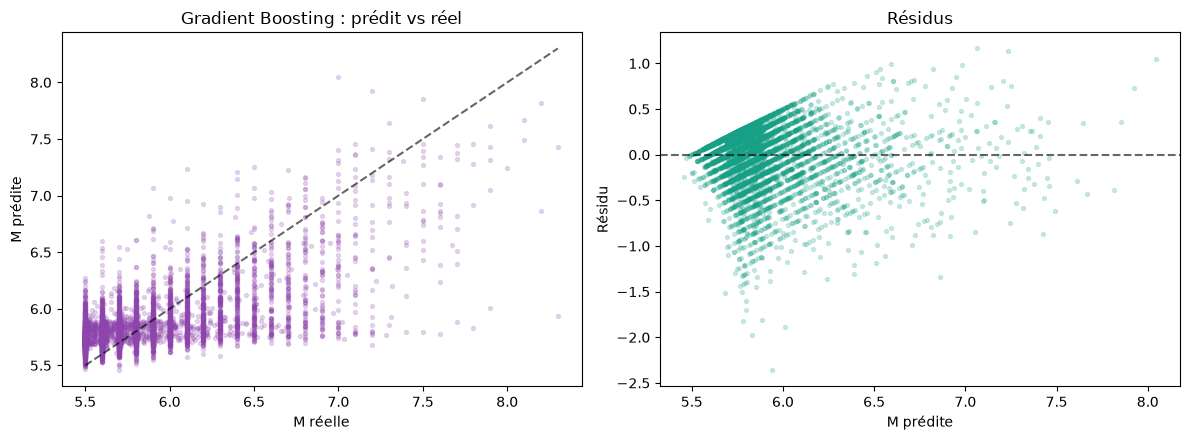

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].scatter(yr_te, best_pred, s=8, alpha=0.2, color="#8e44ad")
lims=[yr_te.min(), yr_te.max()]; ax[0].plot(lims, lims, "k--", alpha=0.6)
ax[0].set(title="Gradient Boosting : prédit vs réel", xlabel="M réelle", ylabel="M prédite")
ax[1].scatter(best_pred, best_pred-yr_te, s=8, alpha=0.2, color="#16a085")
ax[1].axhline(0, color="k", ls="--", alpha=0.6)
ax[1].set(title="Résidus", xlabel="M prédite", ylabel="Résidu")
plt.tight_layout(); plt.show()

## 5. Lecture spatiale — hotspots de subduction

Les événements flaggés tsunami se concentrent sur la **Ceinture de feu du
Pacifique** et les marges de subduction. La carte **interactive** complète est
exportée dans `reports/figures/earthquake_map.html`.

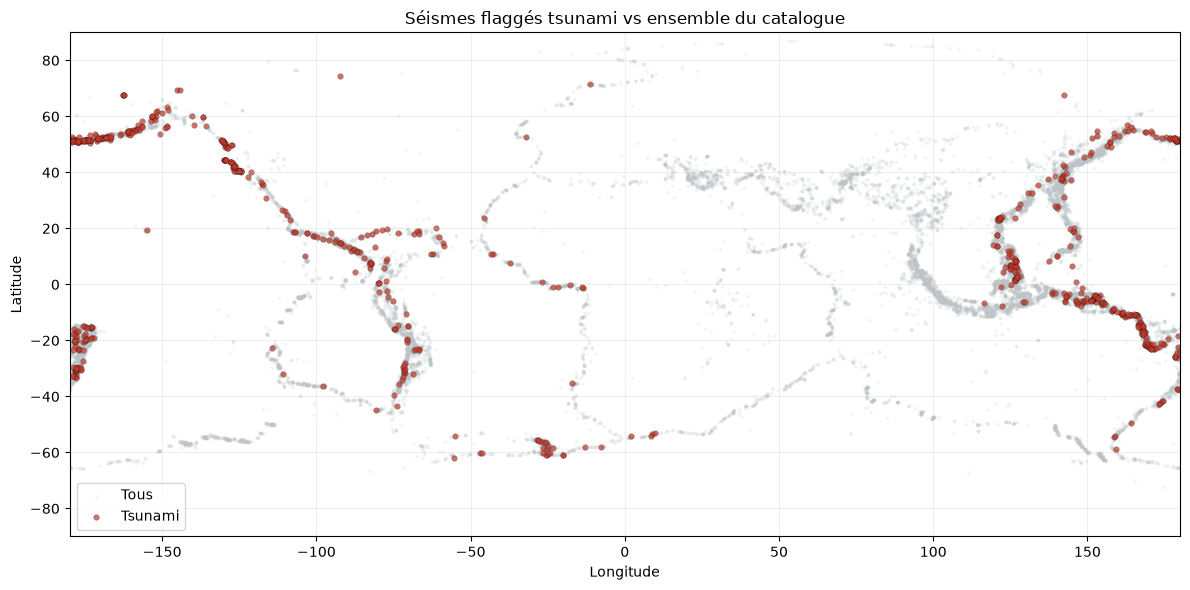

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(df.longitude, df.latitude, s=3, alpha=0.12, color="#bdc3c7", label="Tous")
ts = df[df.tsunami==1]
ax.scatter(ts.longitude, ts.latitude, s=16, alpha=0.7, color="#c0392b",
           edgecolor="k", linewidth=0.2, label="Tsunami")
ax.set(title="Séismes flaggés tsunami vs ensemble du catalogue",
       xlabel="Longitude", ylabel="Latitude", xlim=(-180,180), ylim=(-90,90))
ax.legend(loc="lower left"); ax.grid(alpha=0.2); plt.tight_layout(); plt.show()

## Conclusion

- **Alerte tsunami** : XGBoost atteint ROC-AUC ≈ 0,95 ; en calant le seuil sur un
  rappel de 90 %, on obtient un pré-filtre exploitable pour l'alerte précoce.
- **Magnitude** : le Gradient Boosting réduit le RMSE à ~0,30 (MAE 0,23), au-delà
  du baseline naïf, mais reste limité par la nature du problème.
- **Temporel/spatial** : pas de vraie saisonnalité ; hausse des comptages
  = artefact de détection ; tsunamis concentrés sur les zones de subduction.

Limites détaillées dans le `README.md` (bruit de la cible, biais de détection,
imputation des mesures d'intensité).